In [1]:
# CELL 1 IMPORTS AND PARAMETERS
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ── Periods ───────────────────────────────────────────────────────────────────
IS_START  = '2018-01-01'
IS_END    = '2022-12-31'
OOS_START = '2023-01-01'
OOS_END   = '2025-12-31'

# ── Portfolio Parameters ──────────────────────────────────────────────────────
TOP_N           = 3        # number of top assets to hold at once
SAFE_HAVEN      = 'GLD'   # fallback when < TOP_N assets qualify
COMMISSION_RATE = 0.001   # 0.10% one-way per unit of turnover
RSI_PERIOD      = 14      # RSI period applied to cumulative returns
RSI_THRESHOLD   = 50      # assets below this RSI rank are excluded
CRYPTO_TICKERS  = {'BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD'}

# ── Best ensemble logic per asset (from your backtest results) ────────────────
BEST_LOGIC = {
    'GLD':     ('MAJORITY', 'OR'),
    'SPY':     ('OR',       'OR'),
    'QQQ':     ('MAJORITY', 'MAJORITY'),
    'TQQQ':    ('AND',      'AND'),
    'BTC-USD': ('AND',      'OR'),
    'SOL-USD': ('AND',      'OR'),
    'ETH-USD': ('OR',       'OR'),
    'BNB-USD': ('MAJORITY', 'MAJORITY'),
    'MSFT':    ('OR',       'OR'),
    'AAPL':    ('MAJORITY', 'MAJORITY'),
    'NVDA':    ('OR',       'OR'),
    'SMH':     ('MAJORITY', 'MAJORITY'),
}

# GDX excluded — no valid combo passed minimum trades filter
TICKERS = list(BEST_LOGIC.keys())

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})

print('Parameters defined ✓')
print(f'Universe : {TICKERS}')
print(f'TOP_N={TOP_N}  SAFE_HAVEN={SAFE_HAVEN}  RSI_PERIOD={RSI_PERIOD}  RSI_THRESHOLD={RSI_THRESHOLD}')

Parameters defined ✓
Universe : ['GLD', 'SPY', 'QQQ', 'TQQQ', 'BTC-USD', 'SOL-USD', 'ETH-USD', 'BNB-USD', 'MSFT', 'AAPL', 'NVDA', 'SMH']
TOP_N=3  SAFE_HAVEN=GLD  RSI_PERIOD=14  RSI_THRESHOLD=50


In [2]:
# CELL 2 DATA DOWNLOAD
raw = yf.download(TICKERS, start='2017-01-01', end=OOS_END, auto_adjust=True)

price_data = {}
for ticker in TICKERS:
    try:
        df = pd.DataFrame({
            'Open':   raw['Open'][ticker],
            'High':   raw['High'][ticker],
            'Low':    raw['Low'][ticker],
            'Close':  raw['Close'][ticker],
            'Volume': raw['Volume'][ticker],
        }).dropna()
        price_data[ticker] = df
        print(f'  {ticker}: {len(df)} bars  ({df.index[0].date()} → {df.index[-1].date()})')
    except Exception as e:
        print(f'  {ticker}: FAILED — {e}')

print(f'\nLoaded {len(price_data)} tickers ✓')

[*********************100%***********************]  12 of 12 completed


  GLD: 2261 bars  (2017-01-03 → 2025-12-30)
  SPY: 2261 bars  (2017-01-03 → 2025-12-30)
  QQQ: 2261 bars  (2017-01-03 → 2025-12-30)
  TQQQ: 2261 bars  (2017-01-03 → 2025-12-30)
  BTC-USD: 3286 bars  (2017-01-01 → 2025-12-30)
  SOL-USD: 2091 bars  (2020-04-10 → 2025-12-30)
  ETH-USD: 2974 bars  (2017-11-09 → 2025-12-30)
  BNB-USD: 2974 bars  (2017-11-09 → 2025-12-30)
  MSFT: 2261 bars  (2017-01-03 → 2025-12-30)
  AAPL: 2261 bars  (2017-01-03 → 2025-12-30)
  NVDA: 2261 bars  (2017-01-03 → 2025-12-30)
  SMH: 2261 bars  (2017-01-03 → 2025-12-30)

Loaded 12 tickers ✓


In [3]:
# CELL 3 INDICATOR LIBRARY

# ── SuperTrend ────────────────────────────────────────────────────────────────
def compute_atr(high, low, close, period):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ], axis=1).max(axis=1)
    atr = np.full(len(tr), np.nan)
    atr[period - 1] = tr.iloc[:period].mean()
    alpha = 1.0 / period
    for i in range(period, len(tr)):
        atr[i] = atr[i-1] * (1 - alpha) + tr.iloc[i] * alpha
    return pd.Series(atr, index=close.index)


def supertrend_signal(high, low, close, atr_period, multiplier):
    hl2 = (high + low) / 2.0
    atr = compute_atr(high, low, close, atr_period)
    basic_upper = hl2 + multiplier * atr
    basic_lower = hl2 - multiplier * atr
    n  = len(close)
    fu = np.full(n, np.nan)
    fl = np.full(n, np.nan)
    direction = np.full(n, np.nan)
    c  = close.values
    bu = basic_upper.values
    bl = basic_lower.values
    seed = atr_period
    fu[seed] = bu[seed]
    fl[seed] = bl[seed]
    direction[seed] = 1 if c[seed] > bu[seed] else -1
    for i in range(seed + 1, n):
        if np.isnan(bu[i]):
            continue
        fu[i] = bu[i] if (bu[i] < fu[i-1] or c[i-1] > fu[i-1]) else fu[i-1]
        fl[i] = bl[i] if (bl[i] > fl[i-1] or c[i-1] < fl[i-1]) else fl[i-1]
        if   c[i] > fu[i-1]: direction[i] =  1
        elif c[i] < fl[i-1]: direction[i] = -1
        else:                 direction[i] = direction[i-1]
    dir_s  = pd.Series(direction, index=close.index)
    return (dir_s.shift(1) == 1).astype(float).fillna(0).astype(int)


# ── KAMA ──────────────────────────────────────────────────────────────────────
def kama_signal(close, er_period, fast_period, slow_period):
    fast_sc = 2 / (fast_period + 1)
    slow_sc = 2 / (slow_period + 1)
    c = close.values
    n = len(c)
    kama = np.full(n, np.nan)
    kama[er_period - 1] = c[er_period - 1]
    for i in range(er_period, n):
        direction  = abs(c[i] - c[i - er_period])
        volatility = np.sum(np.abs(np.diff(c[i - er_period: i + 1])))
        er = direction / volatility if volatility != 0 else 0
        sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
        kama[i] = kama[i-1] + sc * (c[i] - kama[i-1])
    kama_s   = pd.Series(kama, index=close.index)
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, n):
        if pd.isna(kama_s.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i] > kama_s.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < kama_s.iloc[i-1]: state = 0
        position.iloc[i] = state
    return position


# ── RSI Rolling Window ────────────────────────────────────────────────────────
def rsi_window_signal(close, rsi_period, window):
    delta    = close.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    rsi      = 100 - (100 / (1 + rs))
    upper    = rsi.rolling(window).quantile(0.80)
    lower    = rsi.rolling(window).quantile(0.20)
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(rsi)):
        up = upper.iloc[i-1]
        lo = lower.iloc[i-1]
        if pd.isna(up) or pd.isna(lo):
            position.iloc[i] = state
            continue
        if state == 0:
            if rsi.iloc[i] > up: state = 1
        else:
            if rsi.iloc[i] < lo: state = 0
        position.iloc[i] = state
    return position


# ── Triple EMA ────────────────────────────────────────────────────────────────
def triple_ema_signal(close, fast, medium, slow):
    ef = close.ewm(span=fast,   adjust=False).mean()
    em = close.ewm(span=medium, adjust=False).mean()
    es = close.ewm(span=slow,   adjust=False).mean()
    bullish = ((ef > em) & (em > es)).astype(int)
    return bullish.shift(1).fillna(0).astype(int)


# ── MACD ──────────────────────────────────────────────────────────────────────
def macd_signal(close, fast, slow, signal):
    ema_fast    = close.ewm(span=fast,   adjust=False).mean()
    ema_slow    = close.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return (macd_line > signal_line).astype(int).shift(1).fillna(0).astype(int)


# ── Donchian Channel ──────────────────────────────────────────────────────────
def donchian_signal(close, high, low, entry_period, exit_period):
    upper_entry = high.rolling(entry_period).max()
    lower_exit  = low.rolling(exit_period).min()
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if state == 0:
            if close.iloc[i] > upper_entry.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < lower_exit.iloc[i-1]:  state = 0
        position.iloc[i] = state
    return position


# ── Bollinger Bands ───────────────────────────────────────────────────────────
def bollinger_signal(close, period, mult):
    middle = close.rolling(window=period).mean()
    std    = close.rolling(window=period).std(ddof=0)
    lower  = middle - mult * std
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if pd.isna(lower.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i-1] > lower.iloc[i-1] and close.iloc[i] <= lower.iloc[i]:
                state = 1
        else:
            if close.iloc[i-1] < middle.iloc[i-1] and close.iloc[i] >= middle.iloc[i]:
                state = 0
        position.iloc[i] = state
    return position


print('Indicator library defined ✓')

Indicator library defined ✓


In [4]:
# CELL 4 SIGNAL CONFIGURATIONS AND ENSEMBLE ENGINE

def build_signals(ticker, df):
    c, h, l = df['Close'], df['High'], df['Low']
    configs = {
        'GLD':     [('MACD(75,226,150)',  lambda: macd_signal(c, 75, 226, 150)),
                    ('3EMA(56,91,116)',   lambda: triple_ema_signal(c, 56, 91, 116)),
                    ('KAMA(49,10,55)',    lambda: kama_signal(c, 49, 10, 55))],
        'SPY':     [('3EMA(6,11,26)',     lambda: triple_ema_signal(c, 6, 11, 26)),
                    ('KAMA(29,2,15)',     lambda: kama_signal(c, 29, 2, 15))],
        'QQQ':     [('MACD(190,266,190)', lambda: macd_signal(c, 190, 266, 190)),
                    ('ST(22,1.5)',        lambda: supertrend_signal(h, l, c, 22, 1.5)),
                    ('KAMA(43,10,20)',    lambda: kama_signal(c, 43, 10, 20))],
        'TQQQ':    [('ST(26,2.5)',        lambda: supertrend_signal(h, l, c, 26, 2.5))],
        'BTC-USD': [('RSI_W(5,165)',      lambda: rsi_window_signal(c, 5, 165)),
                    ('KAMA(7,10,20)',     lambda: kama_signal(c, 7, 10, 20))],
        'SOL-USD': [('RSI_W(28,35)',      lambda: rsi_window_signal(c, 28, 35)),
                    ('MACD(10,21,50)',    lambda: macd_signal(c, 10, 21, 50))],
        'ETH-USD': [('3EMA(6,11,21)',     lambda: triple_ema_signal(c, 6, 11, 21)),
                    ('RSI_W(10,65)',      lambda: rsi_window_signal(c, 10, 65))],
        'MSFT':    [('ST(24,6.0)',        lambda: supertrend_signal(h, l, c, 24, 6.0)),
                    ('KAMA(57,4,60)',     lambda: kama_signal(c, 57, 4, 60))],
        'AAPL':    [('BB(45,0.5)',        lambda: bollinger_signal(c, 45, 0.5)),
                    ('ST(10,2.0)',        lambda: supertrend_signal(h, l, c, 10, 2.0)),
                    ('KAMA(27,2,60)',     lambda: kama_signal(c, 27, 2, 60))],
        'BNB-USD': [('MACD(5,6,5)',       lambda: macd_signal(c, 5, 6, 5)),
                    ('DON(30,17)',        lambda: donchian_signal(c, h, l, 30, 17)),
                    ('ST(8,4.0)',         lambda: supertrend_signal(h, l, c, 8, 4.0))],
        'NVDA':    [('3EMA(46,61,146)',   lambda: triple_ema_signal(c, 46, 61, 146)),
                    ('MACD(210,241,195)', lambda: macd_signal(c, 210, 241, 195))],
        'SMH':     [('KAMA(27,16,25)',    lambda: kama_signal(c, 27, 16, 25)),
                    ('3EMA(86,121,206)',  lambda: triple_ema_signal(c, 86, 121, 206)),
                    ('MACD(17,261,255)',  lambda: macd_signal(c, 17, 261, 255))],
    }
    if ticker not in configs:
        return {}
    signals = {}
    for label, fn in configs[ticker]:
        try:
            signals[label] = fn()
        except Exception as e:
            print(f'  Warning: {ticker} {label} failed — {e}')
    return signals


def apply_logic(signals_arr, mode):
    n = len(signals_arr)
    if mode == 'AND':
        return all(s == 1 for s in signals_arr)
    elif mode == 'OR':
        return any(s == 1 for s in signals_arr)
    elif mode == 'MAJORITY':
        return any(s == 1 for s in signals_arr) if n <= 2 else sum(s == 1 for s in signals_arr) > n / 2
    return False


def run_ensemble(signal_dict, entry_logic, exit_logic):
    labels = list(signal_dict.keys())
    n_ind  = len(labels)
    if n_ind == 0:
        raise ValueError('No signals provided')
    if n_ind == 1:
        return list(signal_dict.values())[0]
    sig_df = pd.DataFrame(signal_dict).fillna(0).astype(int)
    pos    = pd.Series(0, index=sig_df.index, dtype=int)
    state  = 0
    for i in range(1, len(sig_df)):
        row = sig_df.iloc[i].values
        if state == 0:
            if apply_logic(row, entry_logic): state = 1
        else:
            exit_row = [1 - s for s in row]
            if apply_logic(exit_row, exit_logic): state = 0
        pos.iloc[i] = state
    return pos


print('Signal configs & ensemble engine defined ✓')

Signal configs & ensemble engine defined ✓


In [5]:
# CELL 5 BUILD PER ASSEST POSITION SIGNALS

# Build the best ensemble position for every asset across the full date range.
# This is the binary ON/OFF signal from the individual strategy backtests.

print('Building ensemble positions for all assets...')

all_positions = {}   # {ticker: pd.Series(0/1)}
all_closes    = {}   # {ticker: pd.Series}

for ticker in TICKERS:
    if ticker not in price_data:
        print(f'  {ticker}: no price data — skipping')
        continue

    df     = price_data[ticker]
    entry, exit_ = BEST_LOGIC[ticker]
    sigs   = build_signals(ticker, df)

    if not sigs:
        print(f'  {ticker}: no signals built — skipping')
        continue

    pos = run_ensemble(sigs, entry, exit_)
    all_positions[ticker] = pos
    all_closes[ticker]    = df['Close']
    print(f'  {ticker}: done  (entry={entry}, exit={exit_})')

print(f'\nPositions built for {len(all_positions)} assets ✓')

Building ensemble positions for all assets...
  GLD: done  (entry=MAJORITY, exit=OR)
  SPY: done  (entry=OR, exit=OR)
  QQQ: done  (entry=MAJORITY, exit=MAJORITY)
  TQQQ: done  (entry=AND, exit=AND)
  BTC-USD: done  (entry=AND, exit=OR)
  SOL-USD: done  (entry=AND, exit=OR)
  ETH-USD: done  (entry=OR, exit=OR)
  BNB-USD: done  (entry=MAJORITY, exit=MAJORITY)
  MSFT: done  (entry=OR, exit=OR)
  AAPL: done  (entry=MAJORITY, exit=MAJORITY)
  NVDA: done  (entry=OR, exit=OR)
  SMH: done  (entry=MAJORITY, exit=MAJORITY)

Positions built for 12 assets ✓


In [6]:
# CELL 6 RSI MOMENTUM RANKING

# Apply RSI to each asset's cumulative return series.
# This measures the strength of the performance trend, not price.
# Assets below RSI_THRESHOLD (50) are excluded from ranking entirely.

def compute_rsi_series(series, period):
    """Standard Wilder RSI applied to any series (here: cumulative returns)."""
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def build_rsi_ranks(all_closes, period, threshold):
    """
    For each date, compute RSI of cumulative return for each asset,
    filter out those below threshold, rank the rest (1 = strongest).
    Returns DataFrame of ranks (NaN = not eligible).
    """
    # Build cumulative return series for each asset
    cum_rets = {}
    for ticker, close in all_closes.items():
        daily = close.pct_change()
        cum_rets[ticker] = (1 + daily).cumprod()

    cum_df = pd.DataFrame(cum_rets).ffill()

    # RSI on cumulative returns
    rsi_df = pd.DataFrame({
        ticker: compute_rsi_series(cum_df[ticker], period)
        for ticker in cum_df.columns
    })

    # Rank: only assets above threshold, 1 = highest RSI (strongest momentum)
    # Shift by 1 day — use yesterday's RSI to determine today's allocation
    rsi_lagged = rsi_df.shift(1)

    ranks = pd.DataFrame(index=rsi_lagged.index, columns=rsi_lagged.columns, dtype=float)
    for date in rsi_lagged.index:
        row = rsi_lagged.loc[date]
        eligible = row[row >= threshold]
        if eligible.empty:
            ranks.loc[date] = np.nan
        else:
            # Rank descending: rank 1 = highest RSI
            ranked = eligible.rank(ascending=False, method='first')
            ranks.loc[date, ranked.index] = ranked.values

    return ranks, rsi_lagged


print('Building RSI momentum ranks...')
rsi_ranks, rsi_values = build_rsi_ranks(all_closes, RSI_PERIOD, RSI_THRESHOLD)
print(f'RSI ranks built: {rsi_ranks.shape[0]} dates × {rsi_ranks.shape[1]} assets ✓')
print(f'\nSample ranks (last 5 rows):')
display(rsi_ranks.tail())

Building RSI momentum ranks...
RSI ranks built: 3286 dates × 12 assets ✓

Sample ranks (last 5 rows):


,GLD,SPY,QQQ,TQQQ,BTC-USD,SOL-USD,ETH-USD,BNB-USD,MSFT,AAPL,NVDA,SMH
Date,,,,,,,,,,,,
2025-12-26,1.0000,2.0000,4.0000,6.0000,NaN,NaN,NaN,NaN,7.0000,NaN,3.0000,5.0000
2025-12-27,1.0000,2.0000,5.0000,6.0000,NaN,NaN,NaN,NaN,7.0000,NaN,3.0000,4.0000
2025-12-28,1.0000,2.0000,5.0000,6.0000,NaN,NaN,NaN,NaN,7.0000,NaN,3.0000,4.0000
2025-12-29,1.0000,2.0000,5.0000,6.0000,NaN,NaN,NaN,NaN,7.0000,NaN,3.0000,4.0000
2025-12-30,NaN,1.0000,4.0000,5.0000,NaN,NaN,NaN,NaN,6.0000,NaN,2.0000,3.0000


In [7]:
# CELL 7 PORTFOLIO CONSTRUCTION

# Dynamic allocation logic:
#   1. Asset must be in top TOP_N by RSI rank (momentum filter)
#   2. Asset must have ensemble position == 1 (trend filter)
#   3. If < TOP_N qualify, remaining weight goes to SAFE_HAVEN (if eligible)
#   4. If SAFE_HAVEN not eligible either, remainder goes to cash (0 return)
#
# Weight per selected asset = 1 / TOP_N (equal weight)
# 1-day lag already baked in via rsi_ranks shift in Cell 6
# and ensemble positions shift in indicator functions

def build_portfolio_weights(rsi_ranks, all_positions, all_closes,
                             top_n, safe_haven, tickers):
    """
    Returns DataFrame of daily weights per asset.
    Rows sum to 1.0 (or less if in cash).
    """
    # Align everything to a common index
    common_idx = rsi_ranks.index
    pos_df = pd.DataFrame({
        t: all_positions[t].reindex(common_idx, fill_value=0)
        for t in tickers if t in all_positions
    })
    rank_df = rsi_ranks.reindex(columns=pos_df.columns)

    weight_per_slot = 1.0 / top_n
    weights_df = pd.DataFrame(0.0, index=common_idx, columns=pos_df.columns)

    for date in common_idx:
        ranks_today = rank_df.loc[date]
        pos_today   = pos_df.loc[date]

        # Eligible: ranked in top N AND ensemble position is ON
        top_ranked  = ranks_today[ranks_today <= top_n].index.tolist()
        eligible    = [t for t in top_ranked if pos_today.get(t, 0) == 1]

        slots_filled = 0
        for asset in eligible:
            weights_df.loc[date, asset] = weight_per_slot
            slots_filled += 1

        # Fill remaining slots with safe haven if eligible
        remaining = top_n - slots_filled
        if remaining > 0 and safe_haven in pos_df.columns:
            sh_rank    = ranks_today.get(safe_haven, np.nan)
            sh_pos     = pos_today.get(safe_haven, 0)
            # Safe haven eligible if its ensemble is ON
            # (we don't require it to be top-ranked for risk-off)
            if sh_pos == 1:
                safe_weight = remaining * weight_per_slot
                weights_df.loc[date, safe_haven] += safe_weight
            # else: cash (weight stays 0)

    return weights_df


print('Building portfolio weights...')
weights_df = build_portfolio_weights(
    rsi_ranks, all_positions, all_closes,
    TOP_N, SAFE_HAVEN, TICKERS
)

# Quick sanity check
weight_sums = weights_df.sum(axis=1)
print(f'Weight sum stats:')
print(f'  Mean : {weight_sums.mean():.3f}')
print(f'  Min  : {weight_sums.min():.3f}')
print(f'  Max  : {weight_sums.max():.3f}')
print(f'  % days fully invested: {(weight_sums >= 0.999).mean():.1%}')
print(f'  % days in cash:        {(weight_sums < 0.001).mean():.1%}')
print(f'\nPortfolio weights built ✓')

Building portfolio weights...
Weight sum stats:
  Mean : 0.655
  Min  : 0.000
  Max  : 1.000
  % days fully invested: 57.2%
  % days in cash:        26.0%

Portfolio weights built ✓


In [8]:
# CELL 8 PORTFOLIO RETURN AND TRANSACTION COSTS

def build_portfolio_returns(weights_df, all_closes, commission_rate):
    """
    Compute daily portfolio returns net of transaction costs.
    Cost = commission_rate × abs(weight change) summed across assets.
    """
    # Build daily returns for each asset aligned to weights index
    common_idx = weights_df.index
    ret_df = pd.DataFrame(index=common_idx, columns=weights_df.columns, dtype=float)

    for ticker in weights_df.columns:
        if ticker in all_closes:
            close = all_closes[ticker].reindex(common_idx).ffill()
            ret_df[ticker] = close.pct_change()

    ret_df = ret_df.fillna(0.0)

    # Gross daily portfolio return = sum(weight × asset_return)
    gross_ret = (weights_df * ret_df).sum(axis=1)

    # Turnover = sum of absolute daily weight changes
    turnover = weights_df.diff().abs().sum(axis=1)

    # Transaction cost
    costs = turnover * commission_rate

    # Net return
    net_ret = gross_ret - costs

    return net_ret, gross_ret, costs, ret_df


print('Computing portfolio returns...')
net_ret, gross_ret, costs, ret_df = build_portfolio_returns(
    weights_df, all_closes, COMMISSION_RATE
)

# Split IS / OOS
is_mask  = (net_ret.index >= IS_START)  & (net_ret.index <= IS_END)
oos_mask = (net_ret.index >= OOS_START) & (net_ret.index <= OOS_END)

net_ret_is  = net_ret[is_mask]
net_ret_oos = net_ret[oos_mask]

equity_full = (1 + net_ret).cumprod()
equity_is   = (1 + net_ret_is).cumprod()
equity_oos  = (1 + net_ret_oos).cumprod()

print(f'Returns computed ✓')
print(f'  Total cost drag: {costs.sum():.2%} over full period')
print(f'  Avg daily turnover: {costs.mean() / COMMISSION_RATE:.2%}')

Computing portfolio returns...
Returns computed ✓
  Total cost drag: 159.50% over full period
  Avg daily turnover: 48.54%


In [9]:
# CELL 9 PERFORMANCE METRICS

def build_portfolio_returns(weights_df, all_closes, commission_rate):
    """
    Compute daily portfolio returns net of transaction costs.
    Cost = commission_rate × abs(weight change) summed across assets.
    """
    # Build daily returns for each asset aligned to weights index
    common_idx = weights_df.index
    ret_df = pd.DataFrame(index=common_idx, columns=weights_df.columns, dtype=float)

    for ticker in weights_df.columns:
        if ticker in all_closes:
            close = all_closes[ticker].reindex(common_idx).ffill()
            ret_df[ticker] = close.pct_change()

    ret_df = ret_df.fillna(0.0)

    # Gross daily portfolio return = sum(weight × asset_return)
    gross_ret = (weights_df * ret_df).sum(axis=1)

    # Turnover = sum of absolute daily weight changes
    turnover = weights_df.diff().abs().sum(axis=1)

    # Transaction cost
    costs = turnover * commission_rate

    # Net return
    net_ret = gross_ret - costs

    return net_ret, gross_ret, costs, ret_df


print('Computing portfolio returns...')
net_ret, gross_ret, costs, ret_df = build_portfolio_returns(
    weights_df, all_closes, COMMISSION_RATE
)

# Split IS / OOS
is_mask  = (net_ret.index >= IS_START)  & (net_ret.index <= IS_END)
oos_mask = (net_ret.index >= OOS_START) & (net_ret.index <= OOS_END)

net_ret_is  = net_ret[is_mask]
net_ret_oos = net_ret[oos_mask]

equity_full = (1 + net_ret).cumprod()
equity_is   = (1 + net_ret_is).cumprod()
equity_oos  = (1 + net_ret_oos).cumprod()

print(f'Returns computed ✓')
print(f'  Total cost drag: {costs.sum():.2%} over full period')
print(f'  Avg daily turnover: {costs.mean() / COMMISSION_RATE:.2%}')

def full_metrics(returns: pd.Series, equity: pd.Series, label="", periods=252):
    """Compute standard portfolio performance metrics"""
    if len(returns) == 0 or len(equity) == 0:
        return pd.Series({
            'Label': label,
            'CAGR': 0.0,
            'Sharpe': 0.0,
            'MaxDD': 0.0,
            'Calmar': 0.0,
            'WinRate': 0.0,
            'Years': 0.0
        })
    
    # Total return
    total_ret = equity.iloc[-1] / equity.iloc[0] - 1
    
    # Years
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    
    # CAGR
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0.0
    
    # Annualized return & volatility
    ret_ann = returns.mean() * periods
    vol_ann = returns.std() * np.sqrt(periods)
    sharpe = ret_ann / vol_ann if vol_ann > 0 else 0.0
    
    # Max Drawdown
    drawdown = equity / equity.cummax() - 1
    maxdd = drawdown.min()
    
    # Calmar Ratio
    calmar = cagr / abs(maxdd) if maxdd < 0 else np.inf
    
    # Win Rate
    win_rate = (returns > 0).mean()
    
    return pd.Series({
        'Label': label,
        'CAGR': cagr,
        'Sharpe': sharpe,
        'MaxDD': maxdd,
        'Calmar': calmar,
        'WinRate': win_rate,
        'Years': years
    })

Computing portfolio returns...
Returns computed ✓
  Total cost drag: 159.50% over full period
  Avg daily turnover: 48.54%


In [10]:
# CELL 10 BENCHMARK COMPARISON (MAX SHARPE AND MAX OMEGA)

from scipy.optimize import minimize

def max_sharpe_portfolio(ret_df, periods=252, rf=0.04):
    """Find weights that maximise Sharpe ratio (mean-variance optimisation)."""
    mu    = ret_df.mean() * periods
    sigma = ret_df.cov()  * periods
    n     = len(mu)

    def neg_sharpe(w):
        port_ret = w @ mu
        port_vol = np.sqrt(w @ sigma @ w)
        return -(port_ret - rf) / port_vol if port_vol > 0 else 0

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds      = [(0, 1)] * n
    w0          = np.ones(n) / n
    result      = minimize(neg_sharpe, w0, method='SLSQP',
                           bounds=bounds, constraints=constraints)
    return pd.Series(result.x, index=ret_df.columns)


def max_omega_portfolio(ret_df, threshold=0.0, periods=252):
    """
    Find weights that maximise Omega ratio.
    Omega = E[max(R-threshold,0)] / E[max(threshold-R,0)]
    """
    n = ret_df.shape[1]

    def neg_omega(w):
        port_ret = ret_df @ w
        gains    = port_ret[port_ret > threshold] - threshold
        losses   = threshold - port_ret[port_ret <= threshold]
        if losses.sum() == 0:
            return -1e9
        return -(gains.sum() / losses.sum())

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds      = [(0, 1)] * n
    w0          = np.ones(n) / n
    result      = minimize(neg_omega, w0, method='SLSQP',
                           bounds=bounds, constraints=constraints)
    return pd.Series(result.x, index=ret_df.columns)


# Build benchmark using IS returns only (fitted on IS, evaluated on OOS)
is_ret_df  = ret_df[is_mask].copy()
oos_ret_df = ret_df[oos_mask].copy()

# Remove columns with all zeros
is_ret_df  = is_ret_df.loc[:, (is_ret_df != 0).any(axis=0)]
oos_ret_df = oos_ret_df.reindex(columns=is_ret_df.columns).fillna(0)

print('Optimising Max Sharpe portfolio...')
w_sharpe = max_sharpe_portfolio(is_ret_df)

print('Optimising Max Omega portfolio...')
w_omega  = max_omega_portfolio(is_ret_df)

# Evaluate both on OOS
def benchmark_equity(weights, ret_df):
    port_ret = ret_df @ weights
    return (1 + port_ret).cumprod(), port_ret

eq_sharpe_oos, ret_sharpe_oos = benchmark_equity(w_sharpe, oos_ret_df)
eq_omega_oos,  ret_omega_oos  = benchmark_equity(w_omega,  oos_ret_df)

sharpe_bm = full_metrics(ret_sharpe_oos, eq_sharpe_oos,
                          label='Max Sharpe BM (OOS)', periods=252)
omega_bm  = full_metrics(ret_omega_oos,  eq_omega_oos,
                          label='Max Omega BM (OOS)',  periods=252)

# === MAIN STRATEGY OOS METRICS ===
oos_metrics = full_metrics(net_ret_oos, equity_oos, 
                           label='Rotational Strategy (OOS)', periods=252)

print('\n═══ Benchmark Comparison (OOS) ═══\n')
bm_df = pd.DataFrame([oos_metrics, sharpe_bm, omega_bm])
display(bm_df)

print('\n── Max Sharpe weights (IS-fitted) ──')
display(w_sharpe[w_sharpe > 0.01].sort_values(ascending=False).map('{:.1%}'.format))
print('\n── Max Omega weights (IS-fitted) ──')
display(w_omega[w_omega > 0.01].sort_values(ascending=False).map('{:.1%}'.format))

Optimising Max Sharpe portfolio...
Optimising Max Omega portfolio...

═══ Benchmark Comparison (OOS) ═══



,Label,CAGR,Sharpe,MaxDD,Calmar,WinRate,Years
0,Rotational Strategy (OOS),0.7384,1.7498,-0.1883,3.9205,0.4265,2.9952
1,Max Sharpe BM (OOS),0.6166,1.4173,-0.3007,2.0508,0.5324,2.9952
2,Max Omega BM (OOS),0.4702,1.9076,-0.1360,3.4569,0.5507,2.9952



── Max Sharpe weights (IS-fitted) ──


AAPL       33.9%
BNB-USD    26.2%
MSFT       21.5%
SOL-USD    18.4%
dtype: object


── Max Omega weights (IS-fitted) ──


GLD        41.7%
MSFT       21.6%
AAPL       16.8%
BNB-USD    11.3%
SOL-USD     8.6%
dtype: object

═══ Asset Correlation Matrix (IS Buy & Hold Returns) ═══



,GLD,SPY,QQQ,TQQQ,BTC-USD,SOL-USD,ETH-USD,BNB-USD,MSFT,AAPL,NVDA,SMH
GLD,1.0000,0.1100,0.1200,0.1200,0.1300,0.0900,0.1200,0.1100,0.0900,0.0800,0.0900,0.1300
SPY,0.1100,1.0000,0.9300,0.9300,0.2700,0.2700,0.2800,0.2200,0.8500,0.8000,0.7300,0.8400
QQQ,0.1200,0.9300,1.0000,1.0000,0.2800,0.2800,0.2900,0.2200,0.9100,0.8600,0.8200,0.8900
TQQQ,0.1200,0.9300,1.0000,1.0000,0.2800,0.2800,0.2900,0.2200,0.9100,0.8700,0.8200,0.8900
BTC-USD,0.1300,0.2700,0.2800,0.2800,1.0000,0.4600,0.8200,0.6400,0.2600,0.2300,0.2500,0.2700
SOL-USD,0.0900,0.2700,0.2800,0.2800,0.4600,1.0000,0.5700,0.5000,0.2400,0.2500,0.2700,0.2500
ETH-USD,0.1200,0.2800,0.2900,0.2900,0.8200,0.5700,1.0000,0.6400,0.2600,0.2400,0.2500,0.2700
BNB-USD,0.1100,0.2200,0.2200,0.2200,0.6400,0.5000,0.6400,1.0000,0.2000,0.1900,0.2000,0.2100
MSFT,0.0900,0.8500,0.9100,0.9100,0.2600,0.2400,0.2600,0.2000,1.0000,0.7700,0.7200,0.7700
AAPL,0.0800,0.8000,0.8600,0.8700,0.2300,0.2500,0.2400,0.1900,0.7700,1.0000,0.6700,0.7400


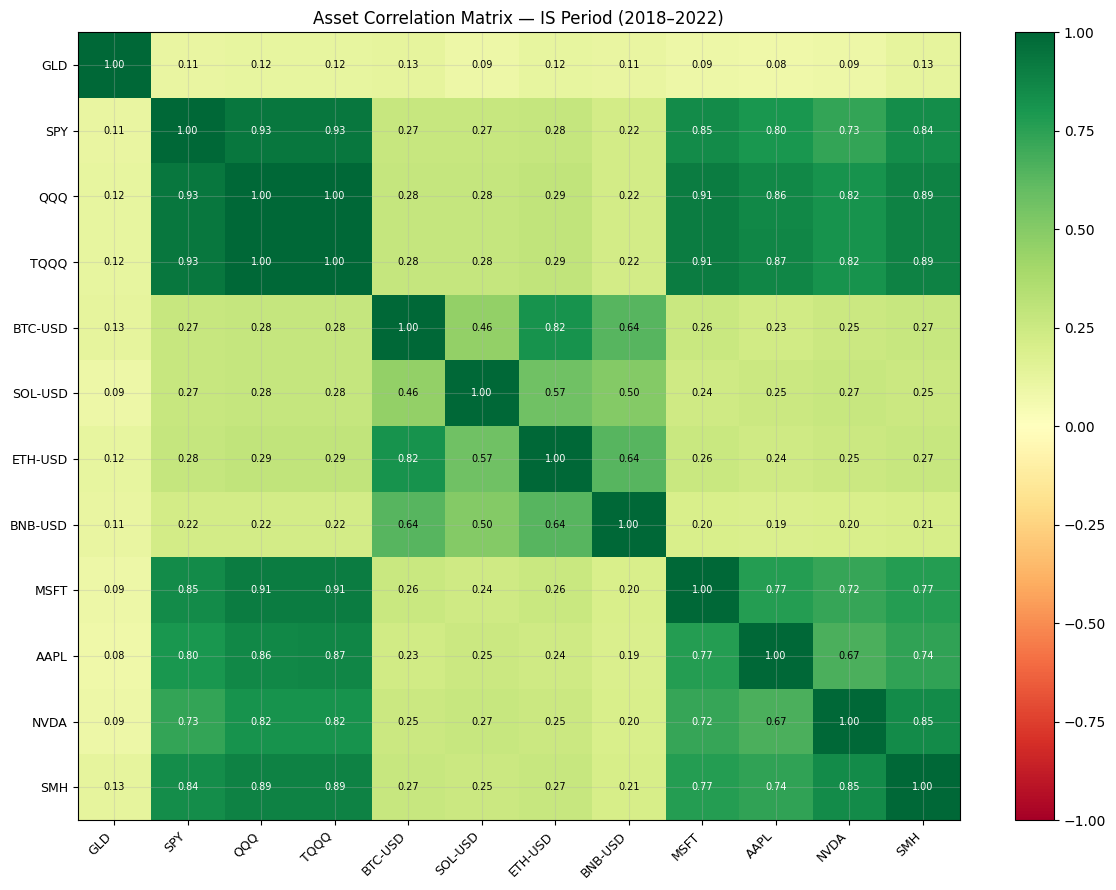

In [11]:
# CELL 11 CORRELATION METRICS

print('═══ Asset Correlation Matrix (IS Buy & Hold Returns) ═══\n')

bnh_rets = pd.DataFrame({
    t: all_closes[t].reindex(ret_df.index).pct_change()
    for t in TICKERS if t in all_closes
})[is_mask]

corr = bnh_rets.corr().round(2)
display(corr)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white')
ax.set_title('Asset Correlation Matrix — IS Period (2018–2022)', fontsize=12)
plt.tight_layout()
plt.show()

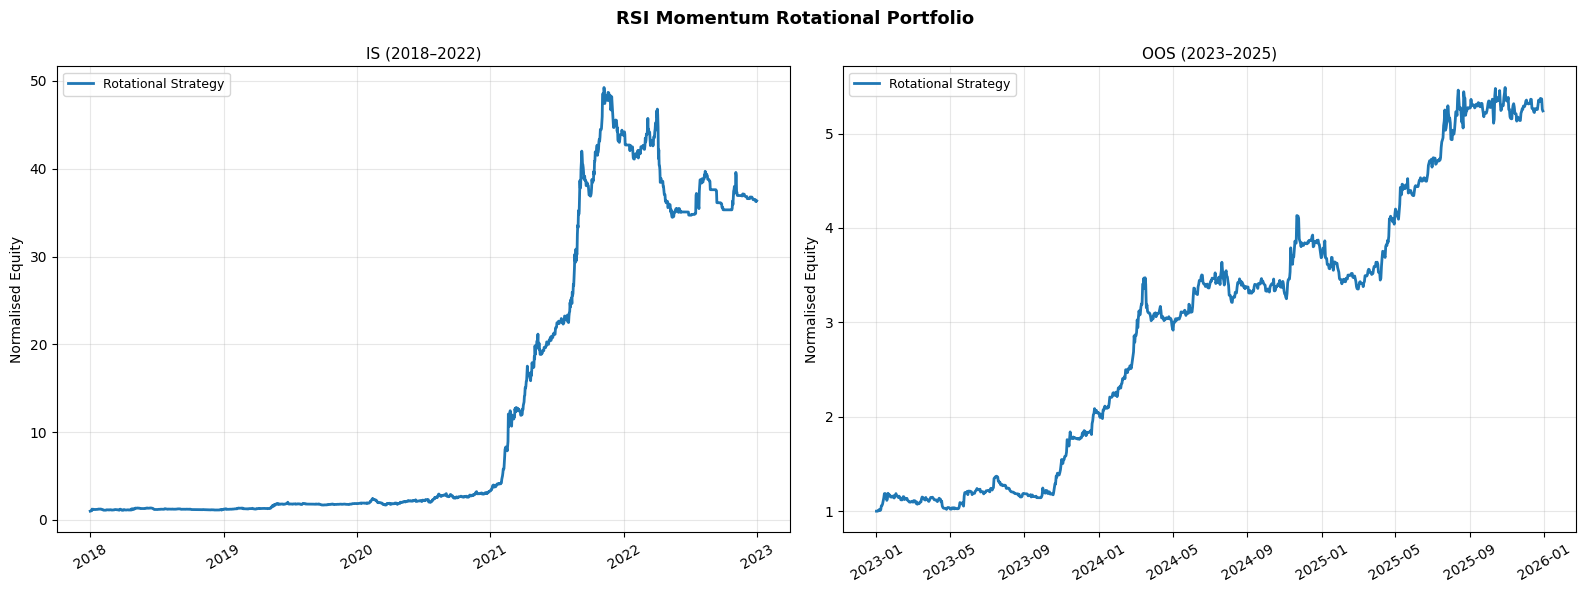

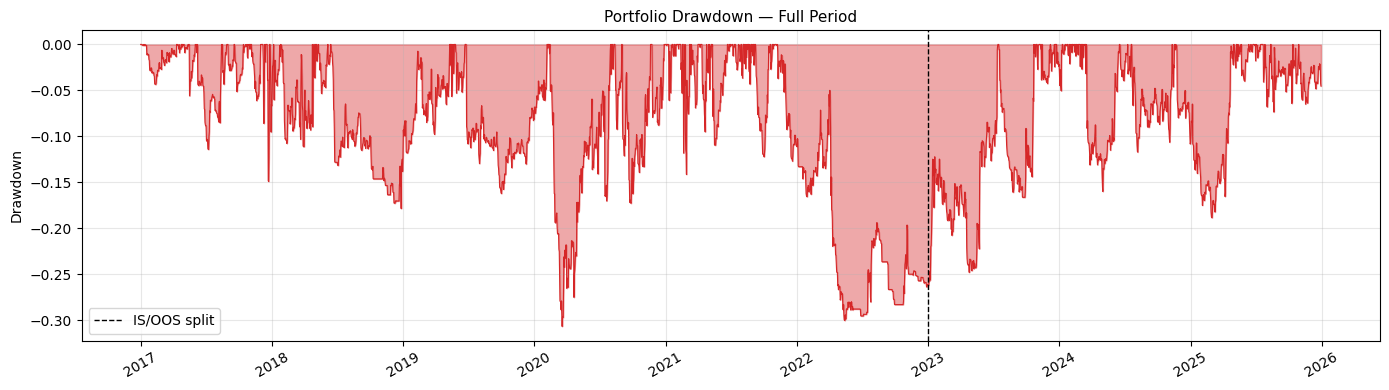

In [12]:
# CELL 12 EQUITY CURVE

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RSI Momentum Rotational Portfolio', fontsize=13, fontweight='bold')

for ax, (phase, mask, net_r, eq) in zip(axes, [
    ('IS (2018–2022)',  is_mask,  net_ret_is,  equity_is),
    ('OOS (2023–2025)', oos_mask, net_ret_oos, equity_oos),
]):
    # Strategy equity
    eq_n = eq / eq.iloc[0]
    ax.plot(eq_n.index, eq_n.values, color='#1f77b4',
            linewidth=2.0, label='Rotational Strategy')

    # Individual asset buy & hold for context
    bh_colors = plt.cm.tab10(np.linspace(0, 1, len(TICKERS)))
    for i, t in enumerate(TICKERS):
        if t not in all_closes:
            continue
        cl   = all_closes[t].reindex(eq.index).ffill()
        bh   = (1 + cl.pct_change()).cumprod()
        bh_n = bh / bh.iloc[0]
        ax.plot(bh_n.index, bh_n.values,
                color=bh_colors[i], linewidth=0.7,
                alpha=0.35, linestyle='--', label=t)

    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Normalised Equity')
    ax.tick_params(axis='x', rotation=30)

    # Only show strategy + top 3 in legend to keep it readable
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1], labels[:1], fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

# ── Drawdown plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
dd = (equity_full - equity_full.cummax()) / equity_full.cummax()
ax.fill_between(dd.index, dd.values, 0, color='#d62728', alpha=0.4)
ax.plot(dd.index, dd.values, color='#d62728', linewidth=0.8)
ax.axvline(pd.Timestamp(OOS_START), color='black', linestyle='--',
           linewidth=1.0, label='IS/OOS split')
ax.set_title('Portfolio Drawdown — Full Period', fontsize=11)
ax.set_ylabel('Drawdown')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

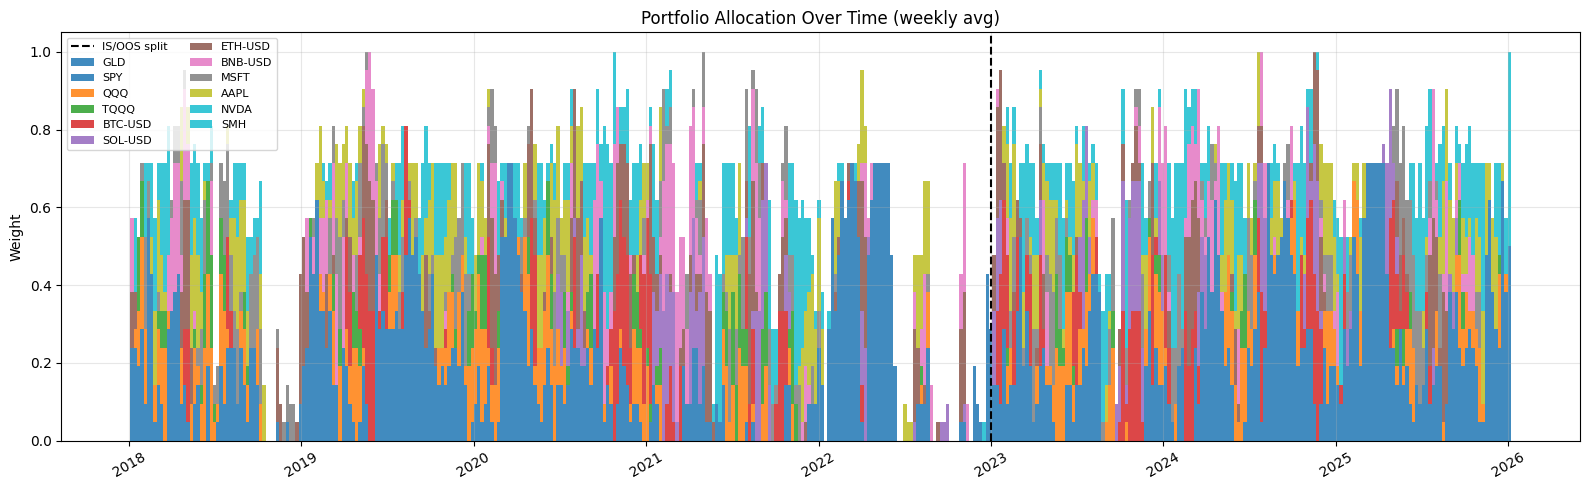


═══ Average Allocation by Asset ═══


GLD        14.3%
AAPL        6.6%
SPY         5.8%
QQQ         5.6%
BTC-USD     5.0%
NVDA        4.9%
MSFT        4.8%
ETH-USD     4.5%
BNB-USD     4.5%
SMH         4.0%
SOL-USD     3.1%
TQQQ        2.4%
Name: Avg Weight, dtype: object


═══ Cash Allocation ═══
  Days in partial/full cash: 42.8%


In [13]:
# CELL 13 ALLOCATION OVER TIME

# Show how the portfolio shifted between assets over time
fig, ax = plt.subplots(figsize=(16, 5))

# Resample to weekly for readability
w_weekly = weights_df.resample('W').mean()
w_weekly = w_weekly.loc[w_weekly.index >= IS_START]

colors = plt.cm.tab10(np.linspace(0, 1, len(weights_df.columns)))
bottom = np.zeros(len(w_weekly))

for i, col in enumerate(weights_df.columns):
    vals = w_weekly[col].fillna(0).values
    ax.bar(w_weekly.index, vals, bottom=bottom,
           color=colors[i], label=col, width=7, alpha=0.85)
    bottom += vals

ax.axvline(pd.Timestamp(OOS_START), color='black', linestyle='--',
           linewidth=1.5, label='IS/OOS split')
ax.set_title('Portfolio Allocation Over Time (weekly avg)', fontsize=12)
ax.set_ylabel('Weight')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# ── Summary stats on allocation ──
print('\n═══ Average Allocation by Asset ═══')
avg_alloc = weights_df.mean().sort_values(ascending=False)
display(avg_alloc.map('{:.1%}'.format).rename('Avg Weight'))

print(f'\n═══ Cash Allocation ═══')
cash_pct = (weights_df.sum(axis=1) < 0.999).mean()
print(f'  Days in partial/full cash: {cash_pct:.1%}')

Data from 2018-01-02 to 2026-05-08

S&P 500 (SPY) Performance Summary (2018–Present)
Period           : 2018-01-02 → 2026-05-08
Total Return     : 211.8%
CAGR             : 14.60%
Max Drawdown     : -33.7%
Years            : 8.3



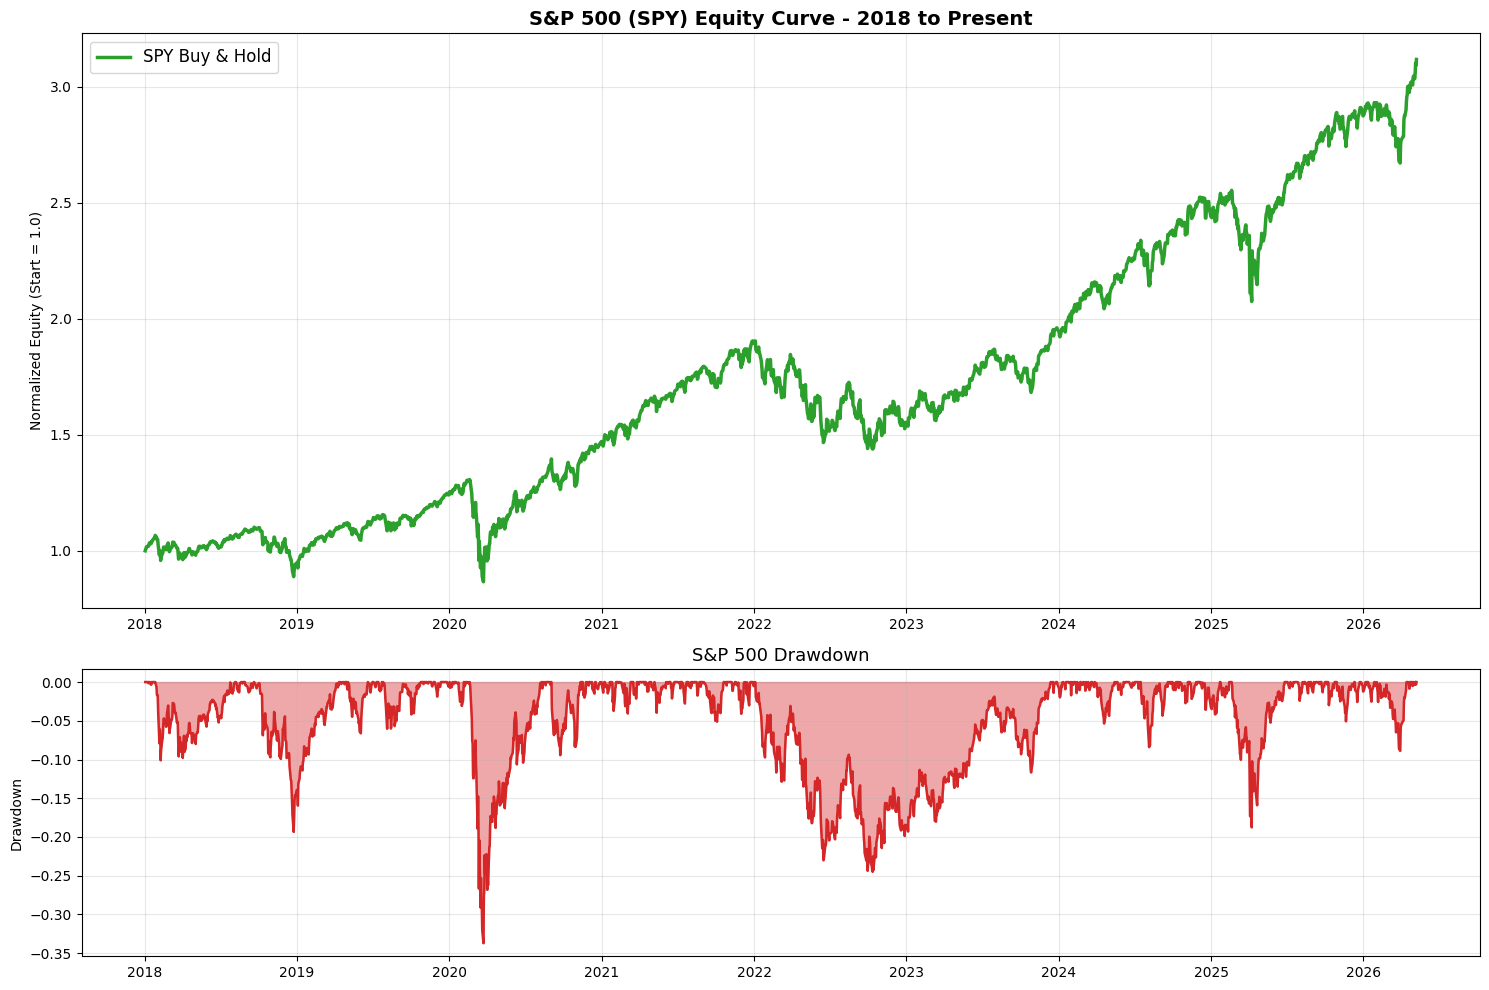


Yearly Returns:
2018: -5.2%
2019: 31.2%
2020: 18.3%
2021: 28.7%
2022: -18.2%
2023: 26.2%
2024: 24.9%
2025: 17.7%


In [15]:
# CELL 15: S&P 500 (SPY) Performance - 2018 to Present

print('Downloading SPY data (S&P 500)...')
spy = yf.download('SPY', start='2018-01-01', end='2026-12-31', 
                  auto_adjust=True, progress=False)['Close']

print(f"Data from {spy.index[0].date()} to {spy.index[-1].date()}\n")

# Calculate returns and equity
spy_ret = spy.pct_change().fillna(0)
spy_equity = (1 + spy_ret).cumprod()

# Drawdown
drawdown = spy_equity / spy_equity.cummax() - 1

# Performance Metrics
total_return = float(spy_equity.iloc[-1] - 1)
years = float((spy.index[-1] - spy.index[0]).days / 365.25)
cagr = float((spy_equity.iloc[-1] ** (1 / years)) - 1)
max_dd = float(drawdown.min())

print(f"{'='*55}")
print("S&P 500 (SPY) Performance Summary (2018–Present)")
print(f"{'='*55}")
print(f"Period           : {spy.index[0].date()} → {spy.index[-1].date()}")
print(f"Total Return     : {total_return:.1%}")
print(f"CAGR             : {cagr:.2%}")
print(f"Max Drawdown     : {max_dd:.1%}")
print(f"Years            : {years:.1f}")
print(f"{'='*55}\n")

# === PLOTS ===
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])

# Equity Curve
ax1 = plt.subplot(gs[0])
ax1.plot(spy_equity, color='#2ca02c', linewidth=2.5, label='SPY Buy & Hold')
ax1.set_title('S&P 500 (SPY) Equity Curve - 2018 to Present', fontsize=14, fontweight='bold')
ax1.set_ylabel('Normalized Equity (Start = 1.0)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)

# Drawdown
ax2 = plt.subplot(gs[1])
ax2.fill_between(drawdown.index, drawdown.values.flatten(), 0, 
                 color='#d62728', alpha=0.4)
ax2.plot(drawdown.index, drawdown.values.flatten(), 
         color='#d62728', linewidth=1.8)
ax2.set_title('S&P 500 Drawdown', fontsize=13)
ax2.set_ylabel('Drawdown')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Yearly Returns - Ultra Safe Version
print("\nYearly Returns:")
for year in range(2018, 2026):
    mask = spy_ret.index.year == year
    if mask.any():
        yearly_ret = (1 + spy_ret[mask]).prod() - 1
        print(f"{year}: {float(yearly_ret):.1%}")

